In [1]:
from classy import Class
import healpy as hp
import numpy as np
import math
import matplotlib.pyplot as plt
import healpy as hp
import scipy.special
cosmo = Class()

In [10]:
cosmo.struct_cleanup()
params = {
    'use_lmbds' : 'y',
    'Omega_Lambda' : '0.',
    'z_lmbds' : '1.'
}
cosmo.set(params)
cosmo.compute()

CosmoComputationError: 

Error in Class: background_init(L:852) :error in background_solve(ppr,pba);
=>background_solve(L:1998) :error in generic_evolver(background_derivs, loga_ini, loga_final, pvecback_integration, used_in_output, pba->bi_size, &bpaw, ppr->tol_background_integration, ppr->smallest_allowed_variation, background_timescale, ppr->background_integration_stepsize, pba->loga_table, pba->bt_size, background_sources, ((void *)0), pba->error_message);
=>evolver_ndf15(L:499) :condition (absh <= hmin) is true; Step size too small: step:5.15779e-14, minimum:5.15779e-14, in interval: [-32.2362:0]


In [2]:
#planc data
pfile="/Users/neenanoble/Dropbox/likelihoods/cosmo/final presentation/planck-tt.txt"
pdobs= np.loadtxt(pfile)
d_o=pdobs[:,1]


In [3]:
#Uncertanity
uplus= pdobs[:,2]
uminus=pdobs[:,3]
av_un= (uplus + uminus)/2
T0 = 2.7255*10**6

In [4]:
def loglikelihood(dt):
    chi_sq=np.sum(((dt - d_o)/av_un)**2)
    return (-1*chi_sq)/2

In [5]:
#theory
lmax= 2508
likes = []
dls=[]
hs=np.arange(0.5,1,0.1)
for i in range (len(hs)):
    cosmo.struct_cleanup()
    params = {
        'output': 'tCl lCl',
        'lensing': 'yes',
        'Omega_m' : '0.3',
        'h' : hs[i]}
    cosmo.set(params)
    cosmo.compute()
    cl = cosmo.raw_cl(lmax)
    cl_tt= cl['tt'][2:]
    L = cl['ell'][2:] 
    t d_= L*(L+1)/((2)*math.pi)*T0**2*cl_tt
    dls.append(d_t)
    likes.append(loglikelihood(d_t)) 
    
print(likes)  


[-85224.7371815534, -16630.347108752358, -1750.4947022524188, -12948.382718487052, -29318.98001259816]


In [5]:
lmax= 2508
likes = []
dls=[]
ks=[-0.1,0,0.5]
for i in range (len(ks)):
    cosmo.struct_cleanup()
    params = {
        'output': 'tCl lCl',
        'lensing': 'yes',
        'Omega_k':str(ks[i])}
    cosmo.set(params)
    cosmo.compute()
    cl = cosmo.raw_cl(lmax)
    cl_tt= cl['tt'][2:]
    L = cl['ell'][2:] 
    d_t = L*(L+1)/((2)*math.pi)*T0**2*cl_tt
    dls.append(d_t)
    likes.append(loglikelihood(d_t)) 

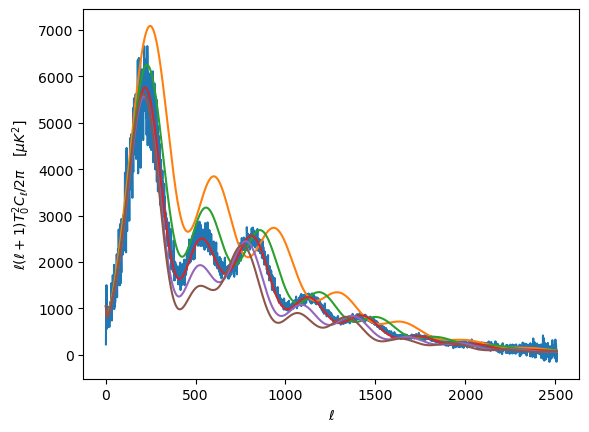

In [6]:
plt.plot(L,d_o)
for i in range(len(hs)):
    plt.plot(L, dls[i])
plt.xlabel(r'$\ell$')
plt.ylabel(r'$\ell(\ell+1)T_0^2C_\ell/2\pi\quad[\mu K^2]$')
plt.show()

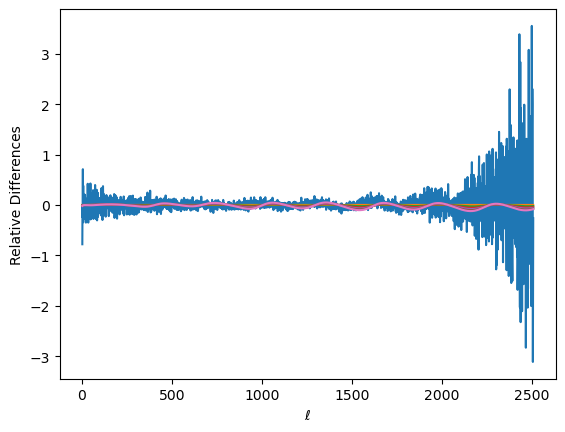

In [9]:
de=(d_o-dls[0])/dls[0]
plt.plot(L,de)
for i in range(len(ms)):
    delta= (dls[i]-dls[0])/dls[0]
    plt.plot(L, delta)
plt.xlabel(r'$\ell$')
plt.ylabel('Relative Differences')
plt.show()


Text(0, 0.5, '$\\ell(\\ell+1)T_0^2C_\\ell/2\\pi\\quad[\\mu K^2]$')

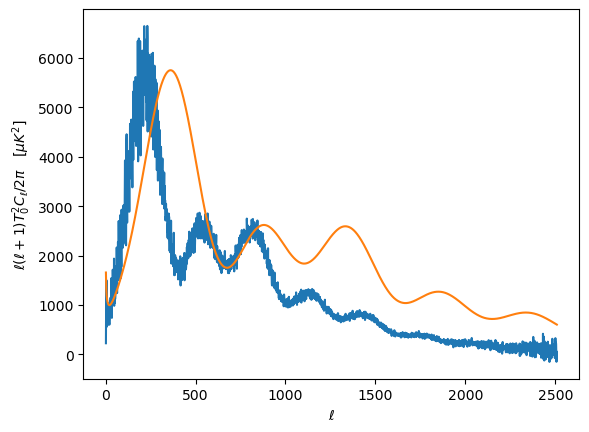

In [16]:
plt.plot(L,d_o)
plt.plot(L,dls[2])
plt.xlabel(r'$\ell$')
plt.ylabel(r'$\ell(\ell+1)T_0^2C_\ell/2\pi\quad[\mu K^2]$')


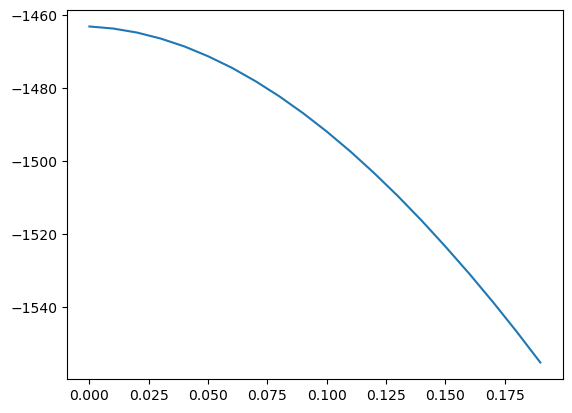

In [7]:
plt.plot(ms,likes)

In [ ]:
plt.plot(L,d_o)
for i in range(len(ms)):
    plt.plot(L, dls[i])
plt.show()

In [9]:
print(type(cl))
cl.keys()

<class 'dict'>


dict_keys(['tt', 'pp', 'tp', 'ell'])

In [7]:
type(cls)
print(1)

1


In [26]:

for i in range(len(ks)):
    likes.append(loglikelihood(d_t))   
print(likes)

[-272707.19992885215, -272707.19992885215, -272707.19992885215]


In [17]:
loglikelihood(d_t)

-272707.1999282531